# LSEG Daily Returns fuer Euro500 Portfolio (Company Cache)

Ziel dieses Notebooks:
- Daily Returns fuer alle Aktien im `euro500` Portfolio ziehen
- RIC-Probleme minimieren: erst ISIN (stabil), nur dann RIC fallback
- Cache **pro Unternehmen** statt pro Quartal
- Finale Tabelle nur fuer Tage, an denen die Aktie im Index ist (exakte Mitgliedschaft)


## 1. Setup


In [87]:
from __future__ import annotations

import hashlib
import random
import re
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import lseg.data as ld

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")

pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"
TABLE_DIR = BASE_DIR / "tables"

CACHE_DIR = DATA_DIR / "daily_returns_cache_by_company"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DATA_DIR / "daily_returns_company_cache_manifest.parquet"
OUTPUT_RETURNS_ALL = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_RETURNS_IN_INDEX = DATA_DIR / "daily_returns_euro500_in_index.parquet"
OUTPUT_MISSING = DATA_DIR / "daily_returns_missing_companies.parquet"
LEGACY_RETURNS_PATH = DATA_DIR / "rets_daily_isin.parquet"

EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"File not found: {EURO500_PATH}")

print("EURO500 path:", EURO500_PATH)
print("Cache dir   :", CACHE_DIR)
print("Legacy file :", LEGACY_RETURNS_PATH, "exists:", LEGACY_RETURNS_PATH.exists())


EURO500 path: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Cache dir   : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_cache_by_company
Legacy file : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/rets_daily_isin.parquet exists: False


## 2. Universe laden und Pull-ID pro Unternehmen bauen

Regel:
1. ISIN (primaer)
2. RIC_current
3. RIC


In [88]:
df = pd.read_parquet(EURO500_PATH).copy()

required = ["quarter", "formation_date", "effective_date", "ISIN", "RIC", "RIC_current"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in euro500: {missing_cols}")

# Ensure firm_id exists (backward compatible with older euro500 versions).
if "firm_id" not in df.columns:
    fid = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)

    df["firm_id"] = fid

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "quarter"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip()
        df.loc[df[c] == "", c] = pd.NA

for c in ["formation_date", "effective_date", "date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Pull-ID je Portfolio-Zeile: ISIN first, sonst RIC_current, sonst RIC.
df["id_type"] = np.select(
    [df["ISIN"].notna(), df["RIC_current"].notna(), df["RIC"].notna()],
    ["ISIN", "RIC", "RIC"],
    default=pd.NA,
)

df["pull_id"] = np.select(
    [df["ISIN"].notna(), df["RIC_current"].notna(), df["RIC"].notna()],
    [df["ISIN"], df["RIC_current"], df["RIC"]],
    default=pd.NA,
)

df["company_key"] = df["id_type"].astype("string") + ":" + df["pull_id"].astype("string")
df.loc[df["pull_id"].isna(), "company_key"] = pd.NA

n_rows = len(df)
n_companies = df["company_key"].nunique(dropna=True)
print(f"Rows in euro500: {n_rows:,}")
print(f"Unique company_key: {n_companies:,}")
print("Rows without pull_id:", int(df["pull_id"].isna().sum()))


Rows in euro500: 54,000
Unique company_key: 1,656
Rows without pull_id: 0


## 3. Exakte Mitgliedschaftsfenster je Quartal

Mitgliedschaft pro Zeile gilt von `effective_date` bis einen Tag vor naechster `effective_date`.


In [89]:
quarter_calendar = (
    df[["quarter", "effective_date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("effective_date")
    .reset_index(drop=True)
)
quarter_calendar["next_effective_date"] = quarter_calendar["effective_date"].shift(-1)

# Ende inklusiv: Tag vor naechster effective_date
max_end = pd.Timestamp.today().normalize()
quarter_calendar["end_date"] = quarter_calendar["next_effective_date"] - pd.Timedelta(days=1)
quarter_calendar["end_date"] = quarter_calendar["end_date"].fillna(max_end)

membership = df.merge(
    quarter_calendar[["quarter", "effective_date", "end_date"]],
    on=["quarter", "effective_date"],
    how="left",
)
membership = membership.rename(columns={"effective_date": "start_date"})

membership = membership.dropna(subset=["company_key", "start_date", "end_date"]).copy()
membership = membership[membership["start_date"] <= membership["end_date"]].copy()

print("Membership rows:", len(membership))
print("Membership companies:", membership["company_key"].nunique())
print("Date range:", membership["start_date"].min().date(), "to", membership["end_date"].max().date())


Membership rows: 54000
Membership companies: 1656
Date range: 1999-01-01 to 2026-02-13


## 4. Cache- und Pull-Helfer

- Ein Cache-File pro `company_key`
- Bei vorhandenem Cache nur fehlende Datumssegmente nachladen


In [90]:
@dataclass
class PullResult:
    df: pd.DataFrame
    field_used: str | None
    mode_used: str | None


def _safe_name(company_key: str) -> str:
    h = hashlib.sha1(company_key.encode("utf-8")).hexdigest()[:12]
    clean = re.sub(r"[^A-Za-z0-9._-]", "_", company_key)
    return f"{clean[:80]}__{h}.parquet"


def cache_path_for_company(company_key: str) -> Path:
    return CACHE_DIR / _safe_name(company_key)


def _extract_single_series(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or raw.empty:
        return pd.DataFrame(columns=["date", "value"])

    w = raw.copy().reset_index()
    if w.empty:
        return pd.DataFrame(columns=["date", "value"])

    # first column after reset_index should be date-like
    date_col = w.columns[0]
    w = w.rename(columns={date_col: "date"})
    w["date"] = pd.to_datetime(w["date"], errors="coerce")
    w = w.dropna(subset=["date"]).copy()

    value_col = None
    best_non_na = -1
    for c in w.columns:
        if c == "date":
            continue
        s = pd.to_numeric(w[c], errors="coerce")
        n = int(s.notna().sum())
        if n > best_non_na:
            best_non_na = n
            value_col = c

    if value_col is None or best_non_na <= 0:
        return pd.DataFrame(columns=["date", "value"])

    out = w[["date", value_col]].copy()
    out = out.rename(columns={value_col: "value"})
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    return out.dropna(subset=["value"]).copy()


def _values_to_returns(s: pd.Series, mode: str) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")

    if mode == "price_level":
        return x.pct_change()

    # mode == return_like: determine percent vs decimal
    abs_q99 = np.nanpercentile(np.abs(x.dropna()), 99) if x.notna().any() else np.nan
    if np.isfinite(abs_q99) and abs_q99 > 1.5:
        return x / 100.0
    return x


def load_legacy_returns(path: Path) -> pd.DataFrame:
    """
    Normalize existing returns file (rets_daily_isin.parquet) to columns:
    date | pull_id | id_type | ret
    """
    if not path.exists():
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    raw = pd.read_parquet(path).copy()

    date_col = "date" if "date" in raw.columns else None
    if date_col is None:
        for c in raw.columns:
            if "date" in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    id_col = None
    for c in ["ISIN", "isin", "Isin"]:
        if c in raw.columns:
            id_col = c
            break
    if id_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    if "ret" in raw.columns:
        ret = pd.to_numeric(raw["ret"], errors="coerce")
    elif "value" in raw.columns:
        v = pd.to_numeric(raw["value"], errors="coerce")
        abs_q99 = np.nanpercentile(np.abs(v.dropna()), 99) if v.notna().any() else np.nan
        ret = v / 100.0 if np.isfinite(abs_q99) and abs_q99 > 1.5 else v
    else:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    out = pd.DataFrame(
        {
            "date": pd.to_datetime(raw[date_col], errors="coerce"),
            "pull_id": raw[id_col].astype("string").str.strip(),
            "id_type": "ISIN",
            "ret": ret,
        }
    )
    out.loc[out["pull_id"] == "", "pull_id"] = pd.NA
    out = out.dropna(subset=["date", "pull_id", "ret"]).copy()
    out = out.sort_values(["pull_id", "date"]).drop_duplicates(["pull_id", "date"], keep="last")
    return out.reset_index(drop=True)


def pull_one_company_returns(
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    max_retries: int = 4,
    base_sleep: float = 0.7,
    verbose: bool = False,
) -> PullResult:
    id_type = (id_type or "").upper()
    if id_type == "ISIN":
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("TR.PriceClose", "price_level"),
        ]
    else:
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("PCTCHNG", "return_like"),
            ("TR.PriceClose", "price_level"),
        ]

    for field, mode in plans:
        last_err = None
        for r in range(max_retries):
            try:
                raw = ld.get_history(
                    universe=[pull_id],
                    fields=[field],
                    start=start.strftime("%Y-%m-%d"),
                    end=end.strftime("%Y-%m-%d"),
                    interval="daily",
                )
                ser = _extract_single_series(raw)
                if ser.empty:
                    break

                ser = ser.sort_values("date")
                ser["ret"] = _values_to_returns(ser["value"], mode=mode)
                ser = ser.dropna(subset=["ret"])[["date", "ret"]].copy()
                if not ser.empty:
                    return PullResult(df=ser, field_used=field, mode_used=mode)
                break
            except Exception as e:
                last_err = e
                sleep_s = base_sleep * (2 ** r) + random.random() * 0.3
                time.sleep(sleep_s)

        if last_err is not None and verbose:
            print(f"[WARN] {pull_id} failed on field {field}: {last_err}")

    return PullResult(df=pd.DataFrame(columns=["date", "ret"]), field_used=None, mode_used=None)


def _load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["date", "ret"])
    d = pd.read_parquet(path)
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["ret"] = pd.to_numeric(d["ret"], errors="coerce")
    return d.dropna(subset=["date", "ret"]).sort_values("date").copy()


def _save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    d.sort_values("date").drop_duplicates(subset=["date"], keep="last").to_parquet(tmp, index=False)
    tmp.replace(path)


def _normalize_seed(seed_returns: pd.DataFrame | None, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if seed_returns is None or seed_returns.empty:
        return pd.DataFrame(columns=["date", "ret"])

    x = seed_returns.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x["ret"] = pd.to_numeric(x["ret"], errors="coerce")
    x = x.dropna(subset=["date", "ret"]).copy()
    x = x[(x["date"] >= start) & (x["date"] <= end)].copy()
    x = x.sort_values("date").drop_duplicates(subset=["date"], keep="last")
    return x[["date", "ret"]]


def update_company_cache(
    company_key: str,
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    force_refresh: bool = False,
    seed_returns: pd.DataFrame | None = None,
    verbose: bool = False,
) -> tuple[pd.DataFrame, str | None, str | None]:
    path = cache_path_for_company(company_key)
    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(path)

    seed = _normalize_seed(seed_returns, start=start, end=end)
    if not seed.empty:
        frames = [x for x in [cached, seed] if not x.empty]
        if frames:
            cached = pd.concat(frames, ignore_index=True)
        else:
            cached = pd.DataFrame(columns=["date", "ret"])
        cached = cached.sort_values("date").drop_duplicates(subset=["date"], keep="last")

    segments: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin, cmax = cached["date"].min(), cached["date"].max()
        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled_parts = []
    field_used = None
    mode_used = None
    for s, e in segments:
        if s > e:
            continue
        res = pull_one_company_returns(
            pull_id=pull_id,
            start=s,
            end=e,
            id_type=id_type,
            verbose=verbose,
        )
        if not res.df.empty:
            pulled_parts.append(res.df)
        field_used = field_used or res.field_used
        mode_used = mode_used or res.mode_used

    if pulled_parts:
        frames = [x for x in [cached] + pulled_parts if not x.empty]
        if frames:
            all_df = pd.concat(frames, ignore_index=True)
        else:
            all_df = pd.DataFrame(columns=["date", "ret"])
    else:
        all_df = cached.copy()

    all_df = all_df.dropna(subset=["date", "ret"]).sort_values("date")
    all_df = all_df.drop_duplicates(subset=["date"], keep="last")

    if not all_df.empty or force_refresh:
        _save_cache(path, all_df)

    return all_df, field_used, mode_used


## 5. Cache aktualisieren (nur neue Unternehmen / fehlende Zeitsegmente)


In [91]:
company_pull_map = (
    membership[["company_key", "pull_id", "id_type"]]
    .dropna(subset=["company_key", "pull_id"])
    .drop_duplicates(subset=["company_key"])
    .reset_index(drop=True)
)

# Pull-Zeitraum aus Mitgliedschaftsfenstern je Unternehmen
span = (
    membership.groupby("company_key", as_index=False)
    .agg(start_date=("start_date", "min"), end_date=("end_date", "max"))
)
company_pull_map = company_pull_map.merge(span, on="company_key", how="left")

# Unternehmens-Metadaten fuer bessere Missing-Analyse
meta_cols = [
    c for c in ["company_key", "name", "firm_id", "ISIN", "RIC", "RIC_current", "hq_country", "hq_code"]
    if c in membership.columns
]
company_meta = (
    membership[meta_cols]
    .dropna(subset=["company_key"])
    .drop_duplicates(subset=["company_key"], keep="first")
    .rename(columns={"name": "company_name"})
)
company_pull_map = company_pull_map.merge(company_meta, on="company_key", how="left")


def _build_id_candidates(row: pd.Series) -> list[tuple[str, str]]:
    """Preferred ID fallback chain per company: ISIN -> RIC_current -> RIC."""
    pairs = [
        ("ISIN", row.get("ISIN", pd.NA)),
        ("RIC", row.get("RIC_current", pd.NA)),
        ("RIC", row.get("RIC", pd.NA)),
    ]

    out: list[tuple[str, str]] = []
    seen: set[tuple[str, str]] = set()
    for id_type, value in pairs:
        if pd.isna(value):
            continue
        v = str(value).strip()
        if not v:
            continue
        key = (id_type, v)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)

    # Ensure previously selected primary ID stays first, if available.
    primary_type = str(row.get("id_type", "")).upper().strip()
    primary_id = row.get("pull_id", pd.NA)
    if pd.notna(primary_id):
        pv = str(primary_id).strip()
        if pv:
            pkey = (primary_type, pv)
            if pkey in out:
                out = [pkey] + [x for x in out if x != pkey]
            else:
                out = [pkey] + out

    return out


company_pull_map["id_candidates"] = company_pull_map.apply(_build_id_candidates, axis=1)
company_pull_map["n_id_candidates"] = company_pull_map["id_candidates"].apply(len)

legacy_returns = load_legacy_returns(LEGACY_RETURNS_PATH)
legacy_by_id = {}
if not legacy_returns.empty:
    for (id_type, pull_id), g in legacy_returns.groupby(["id_type", "pull_id"], dropna=False):
        legacy_by_id[(id_type, pull_id)] = g[["date", "ret"]].copy()

print("Companies to process:", len(company_pull_map))
print("Legacy rows loaded:", len(legacy_returns))
print("Legacy ids loaded  :", len(legacy_by_id))
print("ID candidates stats:", company_pull_map["n_id_candidates"].describe(), sep="\n")
print(company_pull_map[["company_key", "pull_id", "id_type", "n_id_candidates"]].head(3))




Companies to process: 1656
Legacy rows loaded: 0
Legacy ids loaded  : 0
ID candidates stats:
count    1656.000000
mean        2.292874
std         0.558892
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: n_id_candidates, dtype: float64
    company_key   pull_id id_type  n_id_candidates
0   RIC:ORAN.PA   ORAN.PA     RIC                2
1   RIC:TLIT.MI   TLIT.MI     RIC                2
2  RIC:NOKIA.HE  NOKIA.HE     RIC                1


In [92]:
force_refresh = False
PRECHECK_TOL_DAYS = 5

manifest_rows = []
all_company_returns = []
missing_rows = []


def _date_span_from_parquet(path: Path) -> tuple[pd.Timestamp, pd.Timestamp, int]:
    if force_refresh or (not path.exists()):
        return pd.NaT, pd.NaT, 0
    try:
        d = pd.read_parquet(path, columns=["date"])
    except Exception:
        return pd.NaT, pd.NaT, 0

    s = pd.to_datetime(d.get("date"), errors="coerce").dropna()
    if len(s) == 0:
        return pd.NaT, pd.NaT, 0
    return s.min(), s.max(), int(len(s))


def _combine_span(a_min, a_max, b_min, b_max):
    mins = [x for x in [a_min, b_min] if pd.notna(x)]
    maxs = [x for x in [a_max, b_max] if pd.notna(x)]
    cmin = min(mins) if mins else pd.NaT
    cmax = max(maxs) if maxs else pd.NaT
    return cmin, cmax


def _normalize_candidates(cands) -> list[tuple[str, str]]:
    if not isinstance(cands, (list, tuple)):
        return []
    out = []
    seen = set()
    for item in cands:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        id_type = str(item[0]).upper().strip()
        pull_id = str(item[1]).strip()
        if not id_type or not pull_id:
            continue
        key = (id_type, pull_id)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)
    return out


def _seed_from_candidates(id_candidates, start: pd.Timestamp, end: pd.Timestamp) -> tuple[pd.DataFrame, list[str]]:
    parts = []
    sources = []
    for cand_type, cand_id in id_candidates:
        seed_returns = legacy_by_id.get((cand_type, cand_id))
        seed = _normalize_seed(seed_returns, start=start, end=end)
        if seed.empty:
            continue
        s = seed.copy()
        s["_src"] = f"{cand_type}:{cand_id}"
        parts.append(s)
        sources.append(f"{cand_type}:{cand_id}")

    if not parts:
        return pd.DataFrame(columns=["date", "ret"]), []

    all_seed = pd.concat(parts, ignore_index=True)
    all_seed = all_seed.sort_values(["date", "_src"]).drop_duplicates(subset=["date"], keep="last")
    all_seed = all_seed.drop(columns=["_src"])
    return all_seed[["date", "ret"]], sources


# ------------------------------
# Pre-check: cache coverage before any pull
# ------------------------------
pre_rows = []
total = len(company_pull_map)
for _, row in company_pull_map.iterrows():
    company_key = row["company_key"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    seed, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)

    cache_min, cache_max, cache_rows = _date_span_from_parquet(cache_path_for_company(company_key))
    seed_min = seed["date"].min() if not seed.empty else pd.NaT
    seed_max = seed["date"].max() if not seed.empty else pd.NaT

    comb_min, comb_max = _combine_span(cache_min, cache_max, seed_min, seed_max)

    if pd.isna(comb_min) or pd.isna(comb_max):
        pre_status = "no_cache"
    elif (comb_min <= start + pd.Timedelta(days=PRECHECK_TOL_DAYS)) and (comb_max >= end - pd.Timedelta(days=PRECHECK_TOL_DAYS)):
        pre_status = "cache_hit"
    else:
        pre_status = "needs_pull"

    pre_rows.append(
        {
            "company_key": company_key,
            "pre_status": pre_status,
            "cache_rows": cache_rows,
            "cache_min": cache_min,
            "cache_max": cache_max,
            "seed_available": bool(not seed.empty),
            "seed_sources": "|".join(seed_sources),
            "combined_min": comb_min,
            "combined_max": comb_max,
        }
    )

precheck_df = pd.DataFrame(pre_rows)
company_pull_map = company_pull_map.merge(precheck_df, on="company_key", how="left")

status_counts = company_pull_map["pre_status"].value_counts(dropna=False).to_dict()
print("Pre-check status:", status_counts)
print("Pre-check tolerance days:", PRECHECK_TOL_DAYS)

pull_queue = company_pull_map[company_pull_map["pre_status"] != "cache_hit"].copy()
pull_needed = int(len(pull_queue))
print(f"Needs pull: {pull_needed}/{total}")


def _record_result(
    row: pd.Series,
    data: pd.DataFrame,
    field_used: str | None,
    mode_used: str | None,
    selected_id_type: str | None,
    selected_pull_id: str | None,
    tried_ids: list[str],
    seed_available: bool,
) -> None:
    company_key = row["company_key"]
    company_name = row.get("company_name", pd.NA)
    firm_id_meta = row.get("firm_id", pd.NA)
    isin_meta = row.get("ISIN", pd.NA)
    ric_meta = row.get("RIC", pd.NA)
    ric_current_meta = row.get("RIC_current", pd.NA)
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    pre_status = row.get("pre_status", "needs_pull")

    if data.empty:
        reason = "no_data"
        if seed_available:
            reason = "no_data_after_seed"
        missing_rows.append(
            {
                "company_key": company_key,
                "company_name": company_name,
                "firm_id": firm_id_meta,
                "ISIN": isin_meta,
                "RIC": ric_meta,
                "RIC_current": ric_current_meta,
                "pull_id": selected_pull_id,
                "id_type": selected_id_type,
                "start_date": start,
                "end_date": end,
                "reason": reason,
                "tried_ids": "|".join(tried_ids),
            }
        )
    else:
        tmp = data.copy()
        tmp["company_key"] = company_key
        tmp["pull_id"] = selected_pull_id
        tmp["id_type"] = selected_id_type
        all_company_returns.append(tmp)

    manifest_rows.append(
        {
            "company_key": company_key,
            "pull_id": selected_pull_id,
            "id_type": selected_id_type,
            "cache_path": str(cache_path_for_company(company_key)),
            "pre_status": pre_status,
            "rows": int(len(data)),
            "min_date": data["date"].min() if not data.empty else pd.NaT,
            "max_date": data["date"].max() if not data.empty else pd.NaT,
            "field_used": field_used,
            "mode_used": mode_used,
            "seed_available": bool(seed_available),
            "tried_ids": "|".join(tried_ids),
            "updated_at": pd.Timestamp.now(),
        }
    )


# ------------------------------
# Phase 1: cache-only rows (no LSEG pull)
# ------------------------------
cache_rows_df = company_pull_map[company_pull_map["pre_status"] == "cache_hit"].copy()
print(f"Cache-only rows: {len(cache_rows_df)}")

for _, row in cache_rows_df.iterrows():
    company_key = row["company_key"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    selected_id_type = id_candidates[0][0] if id_candidates else row.get("id_type", pd.NA)
    selected_pull_id = id_candidates[0][1] if id_candidates else row.get("pull_id", pd.NA)
    tried_ids = [f"{t}:{i}" for t, i in id_candidates]

    seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)
    seed_available = bool(not seed_all.empty)

    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(cache_path_for_company(company_key))
    frames = [x for x in [cached, seed_all] if not x.empty]
    if frames:
        data = pd.concat(frames, ignore_index=True)
        data = data.dropna(subset=["date", "ret"]).sort_values("date").drop_duplicates(subset=["date"], keep="last")
    else:
        data = pd.DataFrame(columns=["date", "ret"])

    _record_result(
        row=row,
        data=data,
        field_used=None,
        mode_used="cache_only",
        selected_id_type=selected_id_type,
        selected_pull_id=selected_pull_id,
        tried_ids=tried_ids,
        seed_available=seed_available,
    )


# ------------------------------
# Phase 2: only pull queue (with ID fallback)
# ------------------------------
session_open = False
if pull_needed > 0:
    ld.open_session()
    session_open = True

try:
    t0 = time.time()
    pull_total = len(pull_queue)
    milestones = set()
    if pull_total > 0:
        milestones = {max(1, int(np.ceil(pull_total * p / 100.0))) for p in range(5, 101, 5)}

    for i, row in pull_queue.iterrows():
        company_key = row["company_key"]
        start = pd.to_datetime(row["start_date"]).normalize()
        end = pd.to_datetime(row["end_date"]).normalize()

        id_candidates = _normalize_candidates(row.get("id_candidates", []))
        tried_ids = [f"{t}:{pid}" for t, pid in id_candidates]

        seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)
        seed_available = bool(not seed_all.empty)

        data = pd.DataFrame(columns=["date", "ret"])
        field_used = None
        mode_used = None
        selected_id_type = row.get("id_type", pd.NA)
        selected_pull_id = row.get("pull_id", pd.NA)

        # Try IDs in order until we get non-empty series.
        for cand_type, cand_id in id_candidates:
            candidate_seed = legacy_by_id.get((cand_type, cand_id))
            cand_data, cand_field, cand_mode = update_company_cache(
                company_key=company_key,
                pull_id=cand_id,
                start=start,
                end=end,
                id_type=cand_type,
                force_refresh=force_refresh,
                seed_returns=candidate_seed,
                verbose=False,
            )
            if not cand_data.empty:
                data = cand_data
                field_used = cand_field
                mode_used = cand_mode
                selected_id_type = cand_type
                selected_pull_id = cand_id
                break

        _record_result(
            row=row,
            data=data,
            field_used=field_used,
            mode_used=mode_used,
            selected_id_type=selected_id_type,
            selected_pull_id=selected_pull_id,
            tried_ids=tried_ids,
            seed_available=seed_available,
        )

        done = len([x for x in manifest_rows if x.get("pre_status") != "cache_hit"])
        if pull_total > 0 and (done in milestones or done == pull_total):
            elapsed = time.time() - t0
            pct = int(np.floor(100 * done / max(pull_total, 1)))
            print(f"Pull progress: {pct}% ({done}/{pull_total}) | elapsed {elapsed:0.1f}s")

finally:
    if session_open:
        ld.close_session()

SAVE_MANIFEST = True  # Persist run diagnostics for QA/debugging.
manifest_df = pd.DataFrame(manifest_rows)
if SAVE_MANIFEST:
    manifest_df.to_parquet(MANIFEST_PATH, index=False)
    print("Saved manifest:", MANIFEST_PATH)
else:
    print("Manifest not saved (SAVE_MANIFEST=False)")

if all_company_returns:
    returns_all = pd.concat(all_company_returns, ignore_index=True)
else:
    returns_all = pd.DataFrame(columns=["date", "ret", "company_key", "pull_id", "id_type"])

returns_all = returns_all.sort_values(["company_key", "date"]).reset_index(drop=True)
returns_all.to_parquet(OUTPUT_RETURNS_ALL, index=False)
print("Saved company returns:", OUTPUT_RETURNS_ALL, "rows:", len(returns_all))

missing_df = pd.DataFrame(missing_rows)
missing_df.to_parquet(OUTPUT_MISSING, index=False)
print("Saved missing list:", OUTPUT_MISSING, "rows:", len(missing_df))


Pre-check status: {'cache_hit': 1564, 'needs_pull': 61, 'no_cache': 31}
Pre-check tolerance days: 5
Needs pull: 92/1656
Cache-only rows: 1564
Pull progress: 5% (5/92) | elapsed 3.1s
Pull progress: 10% (10/92) | elapsed 31.7s
Pull progress: 15% (14/92) | elapsed 48.0s
Pull progress: 20% (19/92) | elapsed 156.5s
Pull progress: 25% (23/92) | elapsed 185.6s
Pull progress: 30% (28/92) | elapsed 203.1s
Pull progress: 35% (33/92) | elapsed 256.0s
Pull progress: 40% (37/92) | elapsed 275.8s
Pull progress: 45% (42/92) | elapsed 307.8s
Pull progress: 50% (46/92) | elapsed 346.2s
Pull progress: 55% (51/92) | elapsed 415.0s
Pull progress: 60% (56/92) | elapsed 547.9s
Pull progress: 65% (60/92) | elapsed 628.4s
Pull progress: 70% (65/92) | elapsed 673.0s
Pull progress: 75% (69/92) | elapsed 752.9s
Pull progress: 80% (74/92) | elapsed 870.6s
Pull progress: 85% (79/92) | elapsed 917.8s
Pull progress: 90% (83/92) | elapsed 976.2s
Pull progress: 95% (88/92) | elapsed 1058.2s
Pull progress: 100% (92/92)

## 6. Exakt auf Index-Mitgliedschaft filtern

`returns_in_index` enthaelt nur Tage, an denen die Aktie im Portfolio/Index enthalten war.


In [93]:
# Expand membership windows to business days for exact day-level filter
m = membership[[
    "quarter", "start_date", "end_date", "company_key", "firm_id", "ISIN", "RIC", "RIC_current", "pull_id", "id_type"
]].copy()

m = m.dropna(subset=["company_key", "start_date", "end_date"]).copy()

parts = []
for _, r in m.iterrows():
    dates = pd.bdate_range(r["start_date"], r["end_date"], freq="B")
    if len(dates) == 0:
        continue
    part = pd.DataFrame({"date": dates})
    for c in ["quarter", "company_key", "firm_id", "ISIN", "RIC", "RIC_current", "pull_id", "id_type"]:
        part[c] = r[c]
    parts.append(part)

if parts:
    membership_daily = pd.concat(parts, ignore_index=True)
else:
    membership_daily = pd.DataFrame(columns=["date", "quarter", "company_key"])

returns_all = pd.read_parquet(OUTPUT_RETURNS_ALL)
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")

returns_in_index = membership_daily.merge(
    returns_all[["date", "company_key", "ret", "pull_id", "id_type"]],
    on=["date", "company_key"],
    how="left",
    suffixes=("", "_ret"),
)

# keep only dates where we actually have a return
returns_in_index = returns_in_index.dropna(subset=["ret"]).copy()

returns_in_index = returns_in_index.sort_values(["date", "company_key"]).reset_index(drop=True)
returns_in_index.to_parquet(OUTPUT_RETURNS_IN_INDEX, index=False)

print("Saved in-index daily returns:", OUTPUT_RETURNS_IN_INDEX)
print("Rows:", len(returns_in_index))
print("Companies covered:", returns_in_index["company_key"].nunique())
print("Date range:", returns_in_index["date"].min(), "to", returns_in_index["date"].max())


Saved in-index daily returns: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_euro500_in_index.parquet
Rows: 3336240
Companies covered: 1621
Date range: 1999-01-04 00:00:00 to 2026-02-13 00:00:00


## 7. QA: Coverage und Missing


In [94]:
returns_in_index = pd.read_parquet(OUTPUT_RETURNS_IN_INDEX)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype("string")

# Expected membership (denominator) from euro500 universe
universe_q = (
    df.groupby("quarter", as_index=False)
    .agg(n_members=("company_key", "nunique"))
)
universe_q["quarter"] = universe_q["quarter"].astype("string")

coverage_q = (
    returns_in_index
    .groupby("quarter", as_index=False)
    .agg(
        n_obs=("ret", "size"),
        n_companies=("company_key", "nunique"),
        n_dates=("date", "nunique"),
    )
    .merge(universe_q, on="quarter", how="right")
)

coverage_q["n_obs"] = coverage_q["n_obs"].fillna(0).astype(int)
coverage_q["n_companies"] = coverage_q["n_companies"].fillna(0).astype(int)
coverage_q["n_dates"] = coverage_q["n_dates"].fillna(0).astype(int)
coverage_q["n_members"] = coverage_q["n_members"].fillna(0).astype(int)

coverage_q["missing_companies"] = (coverage_q["n_members"] - coverage_q["n_companies"]).clip(lower=0)
coverage_q["coverage_pct"] = np.where(
    coverage_q["n_members"] > 0,
    100.0 * coverage_q["n_companies"] / coverage_q["n_members"],
    np.nan,
)
coverage_q["avg_obs_per_company"] = np.where(
    coverage_q["n_companies"] > 0,
    coverage_q["n_obs"] / coverage_q["n_companies"],
    np.nan,
)

coverage_q = coverage_q.sort_values("quarter").reset_index(drop=True)

print("Coverage (latest 10 quarters):")
print(
    coverage_q.tail(10)[
        ["quarter", "n_members", "n_companies", "missing_companies", "coverage_pct", "n_dates", "avg_obs_per_company"]
    ].to_string(index=False)
)

print("Worst 10 quarters by coverage (%):", sep="\n")
print(
    coverage_q.sort_values(["coverage_pct", "missing_companies"], ascending=[True, False]).head(10)[
        ["quarter", "n_members", "n_companies", "missing_companies", "coverage_pct"]
    ].to_string(index=False)
)

missing_df = pd.read_parquet(OUTPUT_MISSING)
print("Missing companies (all-time):", len(missing_df), sep="\n")
if len(missing_df) > 0:
    print("Missing reasons:")
    print(missing_df["reason"].value_counts(dropna=False).to_string())




Coverage (latest 10 quarters):
quarter  n_members  n_companies  missing_companies  coverage_pct  n_dates  avg_obs_per_company
 2023Q3        500          499                  1          99.8       65            64.212425
 2023Q4        500          500                  0         100.0       64            62.566000
 2024Q1        500          500                  0         100.0       63            62.532000
 2024Q2        500          500                  0         100.0       65            62.456000
 2024Q3        500          500                  0         100.0       66            65.434000
 2024Q4        500          500                  0         100.0       65            62.810000
 2025Q1        500          500                  0         100.0       63            62.528000
 2025Q2        500          500                  0         100.0       64            61.606000
 2025Q3        500          500                  0         100.0       66            65.404000
 2025Q4        500 

### 7.1 Coverage-Plot


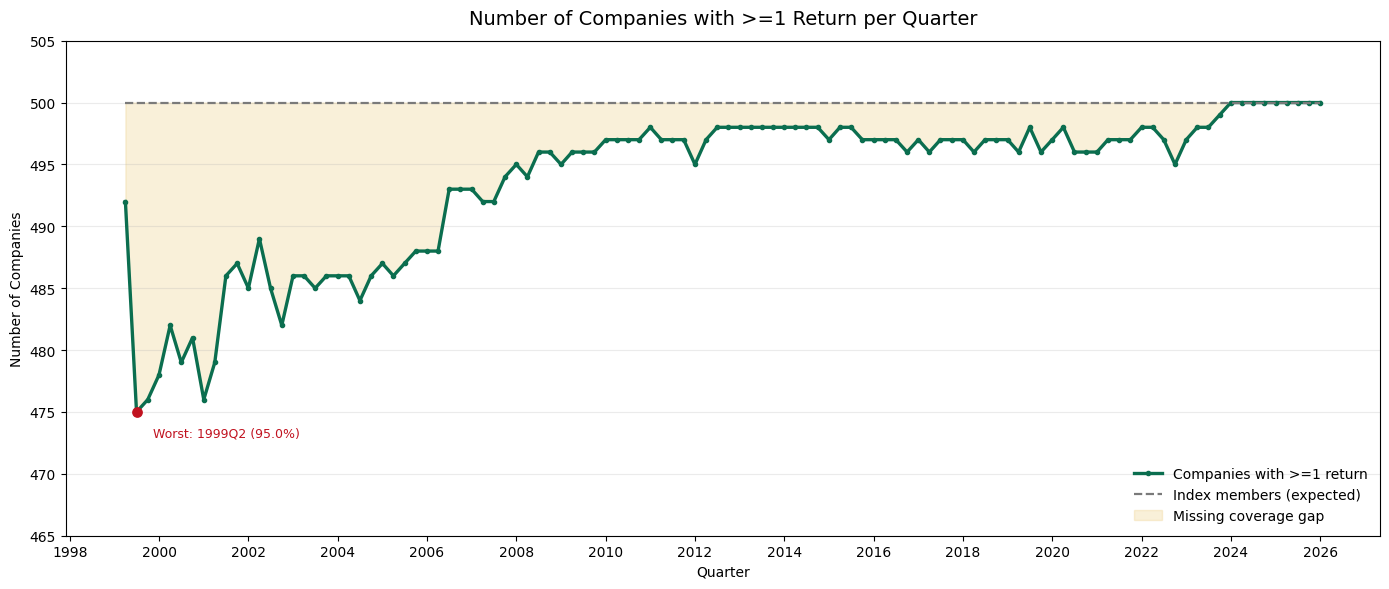

In [95]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_df = coverage_q.copy()
plot_df["quarter_end"] = pd.PeriodIndex(plot_df["quarter"].astype(str), freq="Q").to_timestamp(how="end")

fig, ax = plt.subplots(figsize=(14, 6))

# Main series: companies with >=1 return
ax.plot(
    plot_df["quarter_end"],
    plot_df["n_companies"],
    color="#0B6E4F",
    linewidth=2.4,
    marker="o",
    markersize=3,
    label="Companies with >=1 return",
)

# Expected universe size
ax.plot(
    plot_df["quarter_end"],
    plot_df["n_members"],
    color="#7A7A7A",
    linewidth=1.6,
    linestyle="--",
    label="Index members (expected)",
)

# Visual gap = missing companies
ax.fill_between(
    plot_df["quarter_end"],
    plot_df["n_companies"],
    plot_df["n_members"],
    where=plot_df["n_members"] >= plot_df["n_companies"],
    color="#E9C46A",
    alpha=0.25,
    label="Missing coverage gap",
)

# Annotate worst quarter
worst_idx = plot_df["coverage_pct"].idxmin()
worst = plot_df.loc[worst_idx]
ax.scatter([worst["quarter_end"]], [worst["n_companies"]], color="#C1121F", s=45, zorder=5)
ax.annotate(
    f"Worst: {worst['quarter']} ({worst['coverage_pct']:.1f}%)",
    xy=(worst["quarter_end"], worst["n_companies"]),
    xytext=(12, -18),
    textcoords="offset points",
    color="#C1121F",
    fontsize=9,
)

ax.set_title("Number of Companies with >=1 Return per Quarter", fontsize=14, pad=12)
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Companies")

# Cleaner time axis
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for label in ax.get_xticklabels():
    label.set_rotation(0)

# y-range with margin
ymin = max(0, int(plot_df["n_companies"].min()) - 10)
ymax = int(plot_df["n_members"].max()) + 5
ax.set_ylim(ymin, ymax)

ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()



## 8. Missing-Liste mappen (nur Anzeige, kein Speichern)

Diese Zelle nutzt bestehende Output-Dateien und zeigt ein angereichertes Preview an,
schreibt aber keine weitere Tabelle auf Disk.


In [96]:
# Post-Processing only: keine LSEG-Session, kein neuer Datenpull
# NOTE: No additional files are written in this section.
from pathlib import Path

missing_in = OUTPUT_MISSING
euro_in = EURO500_PATH

if not missing_in.exists():
    raise FileNotFoundError(f"Missing file not found: {missing_in}")
if not euro_in.exists():
    raise FileNotFoundError(f"euro500 file not found: {euro_in}")

missing = pd.read_parquet(missing_in).copy()
euro = pd.read_parquet(euro_in).copy()

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "name", "hq_country", "hq_code"]:
    if c in euro.columns:
        euro[c] = euro[c].astype("string").str.strip()
        euro.loc[euro[c] == "", c] = pd.NA

# company_key wie im Pull-Notebook rekonstruieren, falls in euro500 nicht enthalten
euro["id_type"] = np.select(
    [euro["ISIN"].notna(), euro["RIC_current"].notna(), euro["RIC"].notna()],
    ["ISIN", "RIC", "RIC"],
    default=pd.NA,
)
euro["pull_id"] = np.select(
    [euro["ISIN"].notna(), euro["RIC_current"].notna(), euro["RIC"].notna()],
    [euro["ISIN"], euro["RIC_current"], euro["RIC"]],
    default=pd.NA,
)
euro["company_key"] = euro["id_type"].astype("string") + ":" + euro["pull_id"].astype("string")
euro.loc[euro["pull_id"].isna(), "company_key"] = pd.NA

meta = (
    euro[["company_key", "name", "firm_id", "ISIN", "RIC", "RIC_current", "hq_country", "hq_code"]]
    .dropna(subset=["company_key"])
    .drop_duplicates(subset=["company_key"], keep="first")
    .rename(columns={"name": "company_name"})
)

enriched = missing.merge(meta, on="company_key", how="left", suffixes=("", "_meta"))

for col in ["firm_id", "ISIN", "RIC", "RIC_current"]:
    meta_col = f"{col}_meta"
    if meta_col in enriched.columns:
        if col not in enriched.columns:
            enriched[col] = enriched[meta_col]
        else:
            enriched[col] = enriched[col].fillna(enriched[meta_col])
        enriched = enriched.drop(columns=[meta_col])

ordered = [
    c for c in [
        "company_name", "company_key", "firm_id", "ISIN", "RIC", "RIC_current",
        "pull_id", "id_type", "start_date", "end_date", "reason", "hq_country", "hq_code"
    ] if c in enriched.columns
]
rest = [c for c in enriched.columns if c not in ordered]
enriched = enriched[ordered + rest]

print("Preview only (no file written). Rows:", len(enriched))
print("Rows without company_name:", int(enriched["company_name"].isna().sum()) if "company_name" in enriched.columns else "n/a")
if len(enriched) > 0:
    print(enriched.head(20))



Preview only (no file written). Rows: 31
Rows without company_name: 0
                                     company_name        company_key  \
0                             Berentzen Gruppe AG         RIC:BEZ.DE   
1                          AS Creation Tapeten AG       RIC:ACWNn.DE   
2                             Estoril Sol SGPS SA  ISIN:PTESO0AM0000   
3          Koninklijke Luchtvaart Maatschappij NV  ISIN:NL0000009645   
4         UeSTRA Hannoversche Verkehrsbetriebe AG  ISIN:DE0008250002   
5                                       Plenum AG  ISIN:DE000A161Z44   
6                                    Meta Wolf AG  ISIN:DE000A254203   
7                                    Ls Invest AG  ISIN:DE0006131204   
8                                    Claranova SE  ISIN:FR0004152882   
9   Compania Espanola de Viviendas en Alquiler SA  ISIN:ES0132955016   
10                                     Enapter AG  ISIN:DE000A255G02   
11                                      Westag AG  ISIN:DE00077752